In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
from pathlib import Path

BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data" / "train.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [51]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [52]:
df.isna().sum()[df.isna().sum() > 0] #Checking which one has NA values

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [82]:
corr = df.corr(numeric_only=True)["SalePrice"]
high_corr_features_numeric = corr[corr.abs() >= 0.5].drop("SalePrice").index
high_corr_features_numeric

Index(['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF',
       'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea'],
      dtype='object')

Above we have isolated the numerical features which seem to have a high correlation with the SalePrice. Below, we attempt to plot a scatter matrix for each

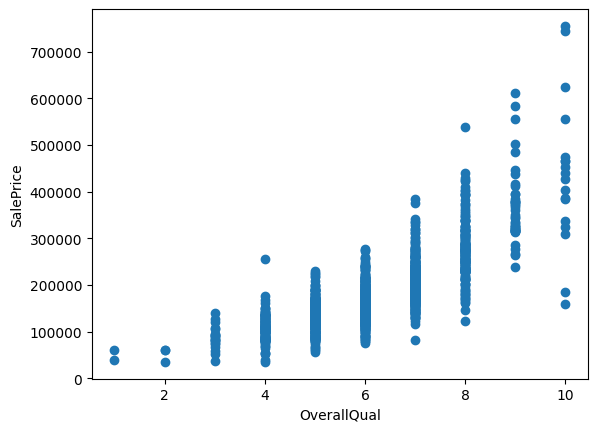

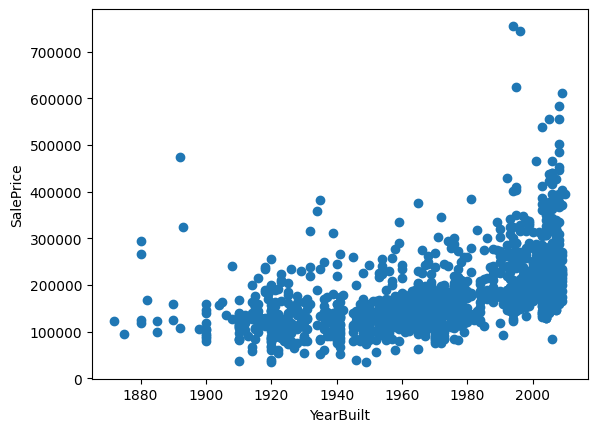

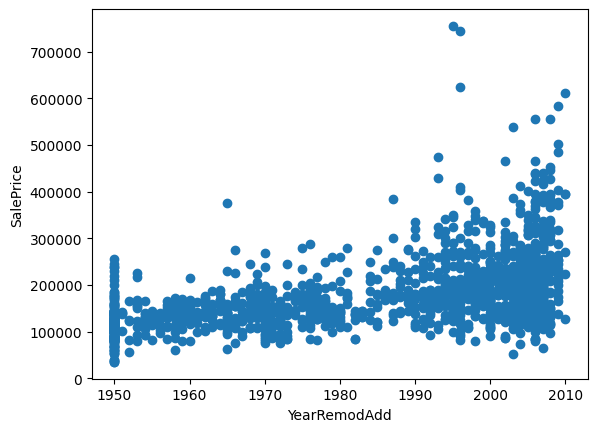

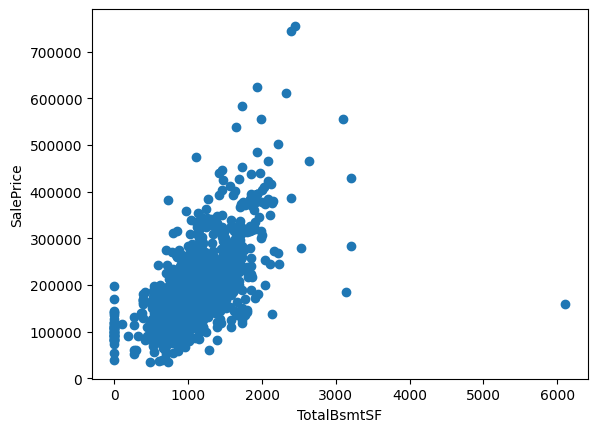

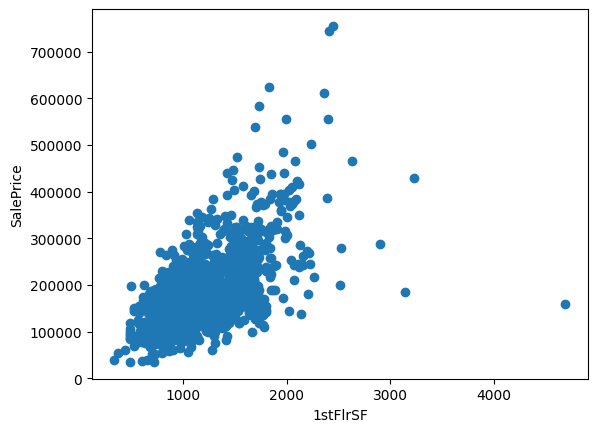

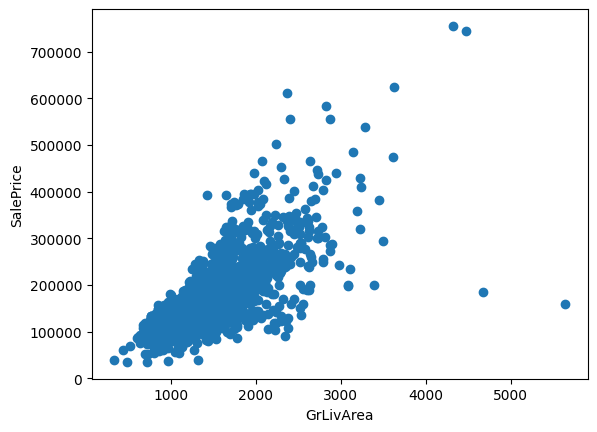

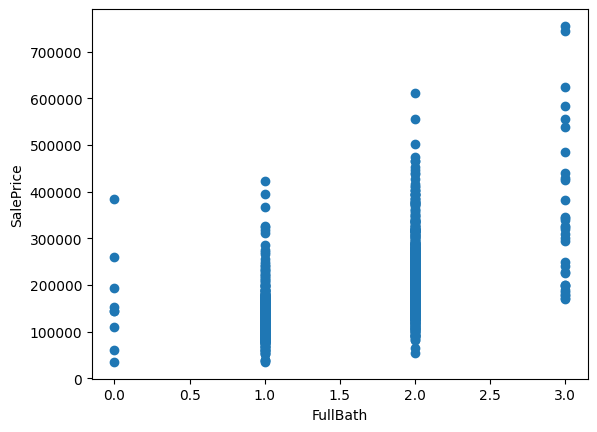

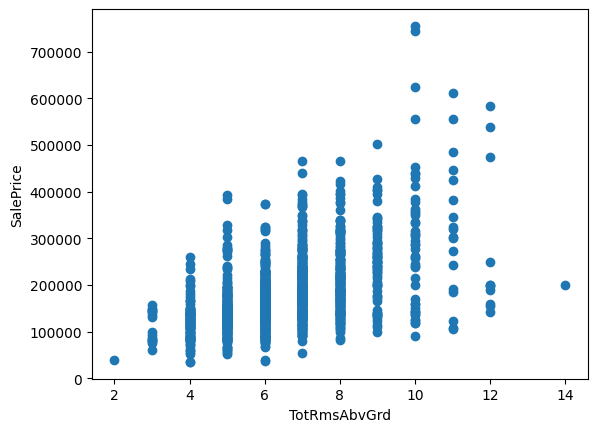

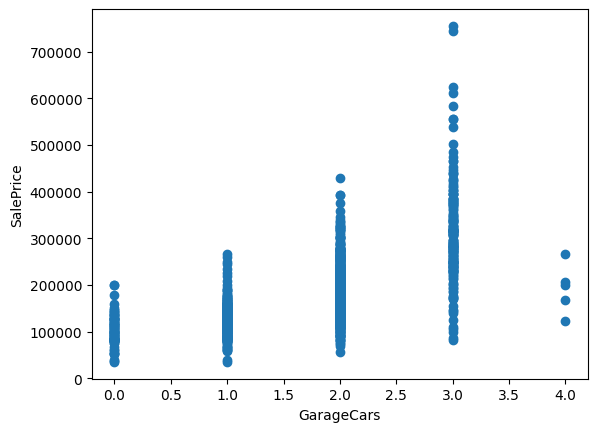

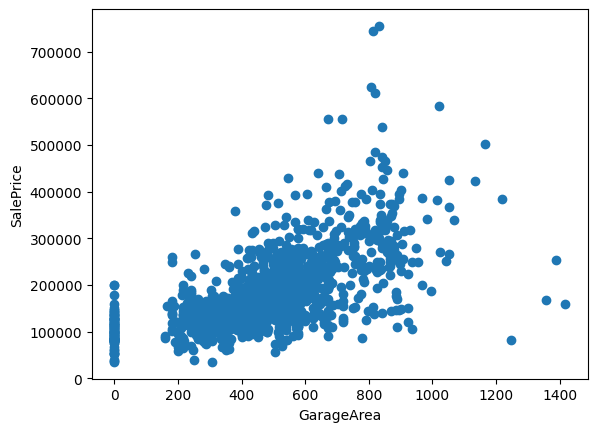

In [83]:
df_high_corr_numeric = df[high_corr_features_numeric]
def scatter(df,x,y):
    plt.scatter(df[x],df[y])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()
for i in high_corr_features_numeric:
    scatter(df,i,"SalePrice")

We can see from the above that SalePrice has an approximate linear relationship with all the isolated features. In some cases, the linear realtionship is very strong. In some, quite weak, with the presence of several outliers in some of the graphs.

We now check how the log of the sale prices relate to the same predictors

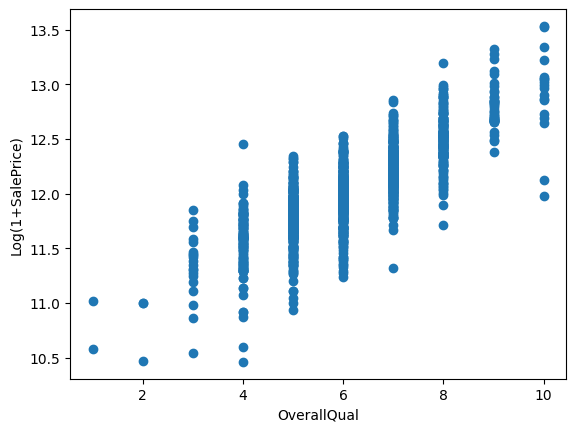

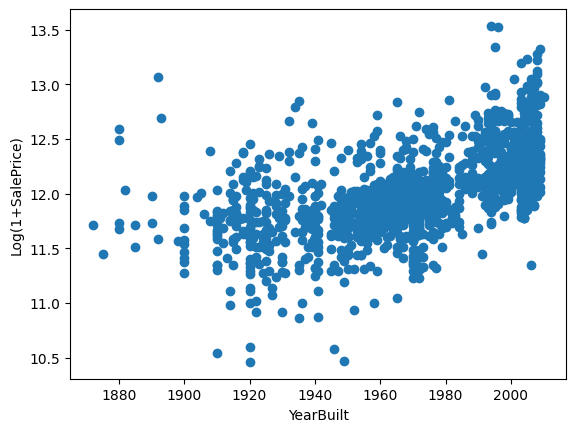

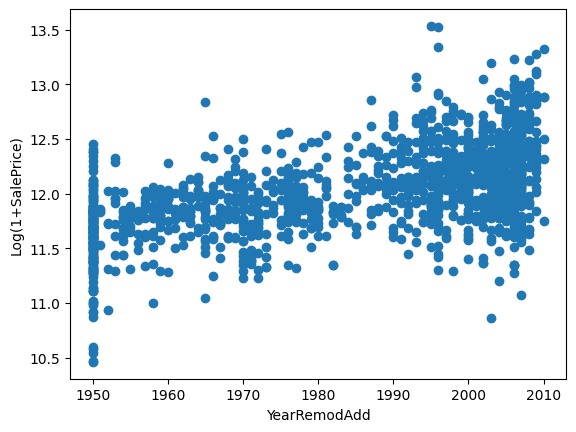

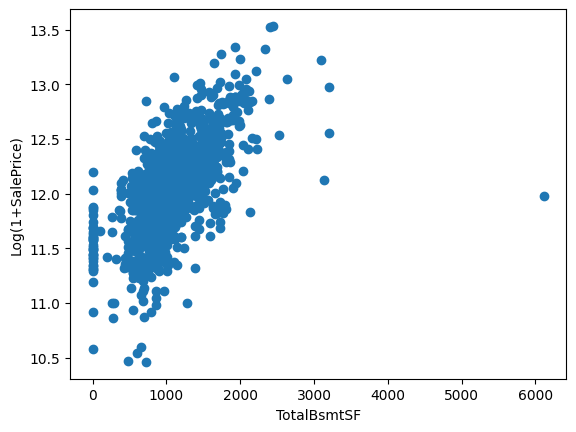

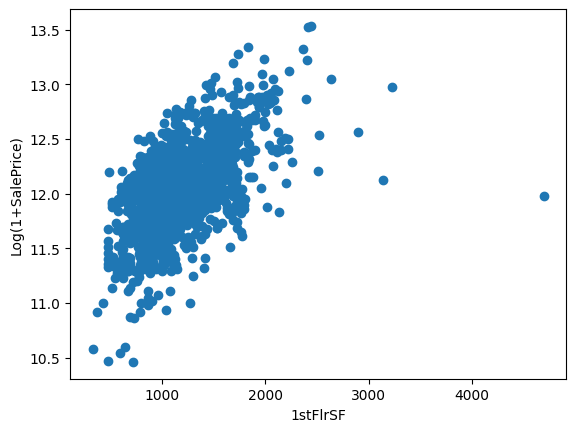

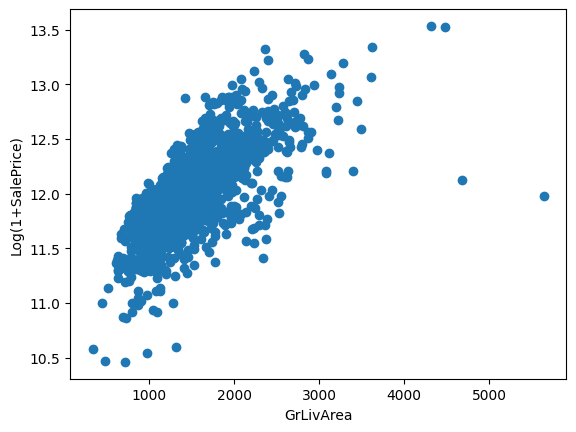

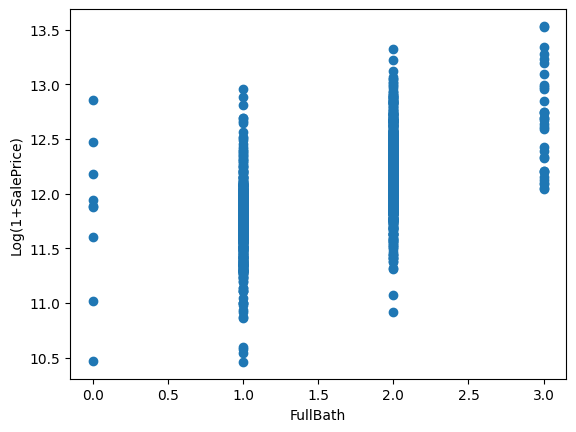

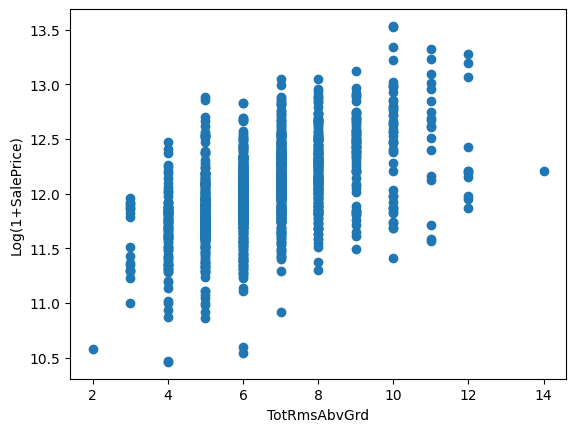

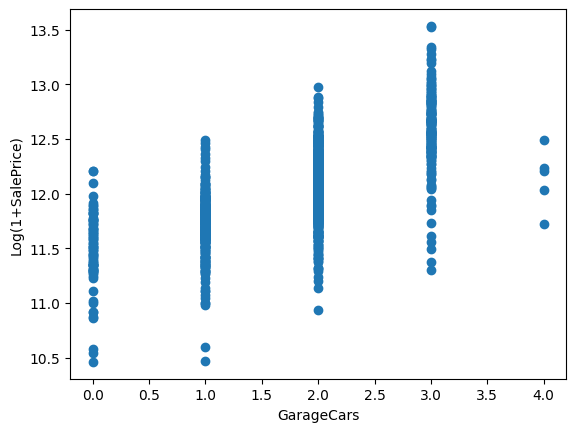

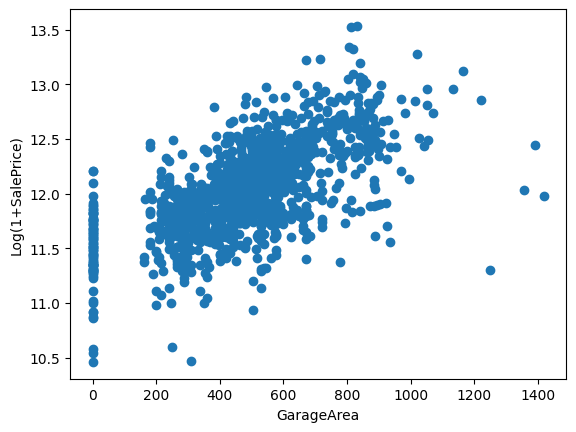

In [94]:
for i in high_corr_features_numeric:
    plt.scatter(df[i],np.log1p(df["SalePrice"]))
    plt.xlabel(i)
    plt.ylabel("Log(1+SalePrice)")
    plt.show()

The linear relationship is much more apparent, and the outliers much more clear with a log transformed response. The outliers do not seem to be of much importance.
We now check the correlation between the above features

In [89]:
c2 = df[high_corr_features_numeric].corr()
c2[c2.abs() > 0.5]

,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,GarageCars,GarageArea
OverallQual,1.000000,0.572323,0.550684,0.537808,NaN,0.593007,0.550600,NaN,0.600671,0.562022
YearBuilt,0.572323,1.000000,0.592855,NaN,NaN,NaN,NaN,NaN,0.537850,NaN
YearRemodAdd,0.550684,0.592855,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalBsmtSF,0.537808,NaN,NaN,1.000000,0.819530,NaN,NaN,NaN,NaN,NaN
1stFlrSF,NaN,NaN,NaN,0.819530,1.000000,0.566024,NaN,NaN,NaN,NaN
GrLivArea,0.593007,NaN,NaN,NaN,0.566024,1.000000,0.630012,0.825489,NaN,NaN
FullBath,0.550600,NaN,NaN,NaN,NaN,0.630012,1.000000,0.554784,NaN,NaN
TotRmsAbvGrd,NaN,NaN,NaN,NaN,NaN,0.825489,0.554784,1.000000,NaN,NaN
GarageCars,0.600671,0.537850,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.882475
GarageArea,0.562022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.882475,1.000000


We can note some strongly correlated features. For example, GarageArea and GarageCars,GrLivArea and TotRmsAbvGrd,1stFlrSF and TotalBsmtSF. These are obvious relationships, and yet we may prefer one over the other in each pair so as to reduce redundancy.

We can move on to explore the relationship between the response and the categorical variables

To run said analysis, we need to fill in the NaN values, as in many categorical variables, the NaN values are not simply errors or missing data, but have actual structural meanings. 

In [97]:
df.isna().sum()[df.isna().sum()>0] #To check which features had more than 0 NaN values

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [98]:
df = df.dropna(subset=["Electrical"]).copy() #As that means, that particular data wasnt collected.

In [99]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

In [100]:
df[df["MasVnrType"].isna()][["MasVnrType","MasVnrArea"]] #Turns out MasVnrArea is 0 wherever MasVnrType is not present. So why the NaN values???
df = df.dropna(subset=["MasVnrArea"]).copy()

In [101]:
df.isna().sum()[df.isna().sum() > 0] #Checking which one has NA values

Alley           1361
MasVnrType       863
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
FireplaceQu      685
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1444
Fence           1170
MiscFeature     1397
dtype: int64

In [102]:
prob = ["Alley","MasVnrType","FireplaceQu","PoolQC","Fence","MiscFeature"] #These are the problem features we shall deal with. We shall deal with Basements and Grages later as they require a different approach.
for i in prob:
    df[i] = df[i].fillna("None")

In [103]:
df.isna().sum()[df.isna().sum() > 0] #Checking which one has NA values

BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
GarageType      81
GarageYrBlt     81
GarageFinish    81
GarageQual      81
GarageCond      81
dtype: int64

In [105]:
no_bsmt = df["TotalBsmtSF"] == 0 #Structural absence should correspond to TotalBsmtSF == 0.

If a house has no basement, all categorical basement features should be NA.

We convert structural NA into an explicit category "None":

In [106]:
bsmt_cat_cols = [
    "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2"
]

df.loc[no_bsmt, bsmt_cat_cols] = df.loc[no_bsmt, bsmt_cat_cols].fillna("None")


There are a few rows where:

- Basement exists (TotalBsmtSF > 0)

- But one categorical variable is missing (usually BsmtExposure)

For those, we impute using mode (only among houses that have basements):

In [107]:
for col in bsmt_cat_cols:
    df.loc[~no_bsmt & df[col].isna(), col] = \
        df.loc[~no_bsmt, col].mode()[0]


For houses with no basement:

Numeric basement variables should already be 0.

If any numeric basement NA exists (rare), set them to 0:

In [108]:
bsmt_num_cols = [
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath"
]

df[bsmt_num_cols] = df[bsmt_num_cols].fillna(0)

In [109]:
df.isna().sum()[df.isna().sum()>0]

GarageType      81
GarageYrBlt     81
GarageFinish    81
GarageQual      81
GarageCond      81
dtype: int64

Now we deal with Garage related features. Since we only want to a analysis of the relationship strength between categorical features and response via correlation ratio, we simply fill in the NA values and ignore GarageYrBlt for now, as that is numeric.

In [110]:
garage_cat_cols = [
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond"
]

df[garage_cat_cols] = df[garage_cat_cols].fillna("None")

In [116]:
y_bar = df["SalePrice"].mean()
SS_total = np.sum((df["SalePrice"] - y_bar)**2)
def cat_anal(feature): #Returns correlation ratio
    SS_bet = 0
    f = set(df[feature])
    for i in f:
        ni = len(df[df[feature]==i])
        yi_bar = (df[df[feature]==i])["SalePrice"].mean()
        SS_bet = ni*((yi_bar-y_bar)**2)
    return np.sqrt(SS_bet/SS_total)

In [124]:
strong_cat = []
for i in df.columns:
    if df[i].dtype == "O":
        c = cat_anal(i)
        if c >= 0.2:
            strong_cat.append((i,c))

In [125]:
strong_cat

[('RoofStyle', np.float64(0.21418493912765435)),
 ('ExterQual', np.float64(0.361665877300951)),
 ('CentralAir', np.float64(0.24320878074328858)),
 ('KitchenQual', np.float64(0.3655027075203735)),
 ('FireplaceQu', np.float64(0.3434674110158603)),
 ('GarageType', np.float64(0.23037571834769732)),
 ('GarageFinish', np.float64(0.3132925473916825)),
 ('GarageQual', np.float64(0.23037571834769732)),
 ('GarageCond', np.float64(0.23037571834769732)),
 ('PavedDrive', np.float64(0.2060165160869266))]

Using the correlation ratio (η) to measure variance explained in SalePrice, the following categorical variables show meaningful separation:

- KitchenQual (η ≈ 0.36)

- FireplaceQu (η ≈ 0.34)

- ExterQual (η ≈ 0.36)

- GarageFinish (η ≈ 0.31)

- GarageType / GarageQual / GarageCond (η ≈ 0.20–0.23)

- CentralAir, RoofStyle, PavedDrive (weaker but non-negligible)

Interpretation

- Quality-related variables (Kitchen, Exterior, Fireplace) show strong separation in price.

- Garage-related categorical features show moderate explanatory power.

- Infrastructure indicators (CentralAir, PavedDrive) have smaller but noticeable effects.

No categorical variable approaches extremely high η (>0.5), indicating that price variation is influenced by multiple interacting factors rather than a single dominant categorical driver.

Conclusion

Categorical variables with η ≥ 0.2 will be retained for modeling.
Lower η variables will not be discarded yet but are lower priority.